In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
 # Upload housing.csv

data = pd.read_csv('housing.csv.zip')
print("Shape:", data.shape)
data.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# 1. Fill missing values in total_bedrooms with median
data['total_bedrooms'].fillna(data['total_bedrooms'].median(), inplace=True)

# 2. Encode categorical column 'ocean_proximity'
data = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True)

print("Shape after preprocessing:", data.shape)
print("Columns:", data.columns.tolist())
data.head()

Shape after preprocessing: (20640, 13)
Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


/tmp/ipykernel_280/2306856435.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['total_bedrooms'].fillna(data['total_bedrooms'].median(), inplace=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [7]:
X = data.drop('median_house_value', axis=1).values.astype(np.float64)   # ← add .astype(np.float64)
y = data['median_house_value'].values.reshape(-1, 1).astype(np.float64)

print("X dtype:", X.dtype)
print("X shape:", X.shape)
print("y shape:", y.shape)

X dtype: float64
X shape: (20640, 12)
y shape: (20640, 1)


In [8]:
def normalize(X):
    mean = np.mean(X, axis=0)
    std  = np.std(X, axis=0, dtype=np.float64)   # ← force float64
    std[std == 0] = 1                              # ← avoid division by zero for constant columns
    return (X - mean) / std, mean, std

X_norm, X_mean, X_std = normalize(X)

# Normalize target
y_mean = np.mean(y)
y_std  = np.std(y, dtype=np.float64)
y_norm = (y - y_mean) / y_std

# Add bias column
X_bias = np.hstack([np.ones((X_norm.shape[0], 1)), X_norm])

print("X dtype after normalize:", X_norm.dtype)
print("X_bias shape:", X_bias.shape)

X dtype after normalize: float64
X_bias shape: (20640, 13)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bias, y_norm,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (16512, 13) | Test: (4128, 13)


In [10]:
def compute_loss(X, y, weights):
    m = len(y)
    predictions = X @ weights
    loss = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return loss

def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    m, n    = X.shape
    weights = np.zeros((n, 1))
    losses  = []

    for epoch in range(epochs):
        predictions = X @ weights
        error       = predictions - y
        gradient    = (1 / m) * (X.T @ error)
        weights    -= learning_rate * gradient

        loss = compute_loss(X, y, weights)
        losses.append(loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch:>5} | Loss: {loss:.6f}")

    return weights, losses

weights, losses = gradient_descent(X_train, y_train, learning_rate=0.01, epochs=1000)
print("\nTraining complete!")

Epoch     0 | Loss: 0.493843
Epoch   100 | Loss: 0.219388
Epoch   200 | Loss: 0.194690
Epoch   300 | Loss: 0.189563
Epoch   400 | Loss: 0.187130
Epoch   500 | Loss: 0.185468
Epoch   600 | Loss: 0.184191
Epoch   700 | Loss: 0.183166
Epoch   800 | Loss: 0.182325
Epoch   900 | Loss: 0.181625

Training complete!


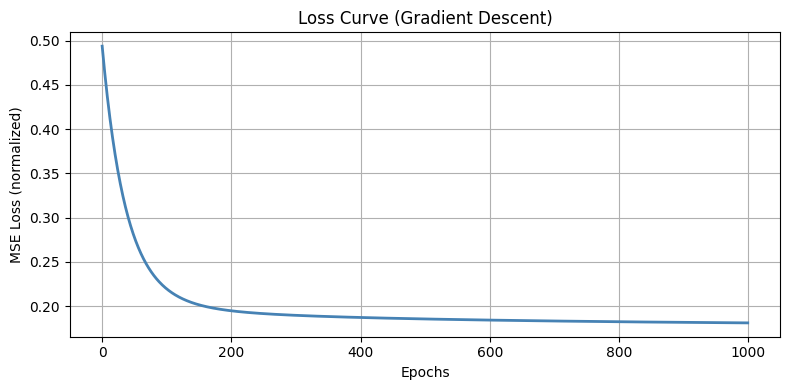

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue', linewidth=2)
plt.title("Loss Curve (Gradient Descent)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss (normalized)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# Predict & denormalize back to original scale
y_pred_norm = X_test @ weights
y_pred      = (y_pred_norm * y_std) + y_mean
y_actual    = (y_test * y_std) + y_mean

mse  = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_actual, y_pred)

print("=" * 40)
print("       MODEL PERFORMANCE REPORT")
print("=" * 40)
print(f"  MSE   : {mse:,.2f}")
print(f"  RMSE  : {rmse:,.2f}")
print(f"  R²    : {r2:.4f}")
print("=" * 40)

       MODEL PERFORMANCE REPORT
  MSE   : 4,970,808,507.86
  RMSE  : 70,503.96
  R²    : 0.6207


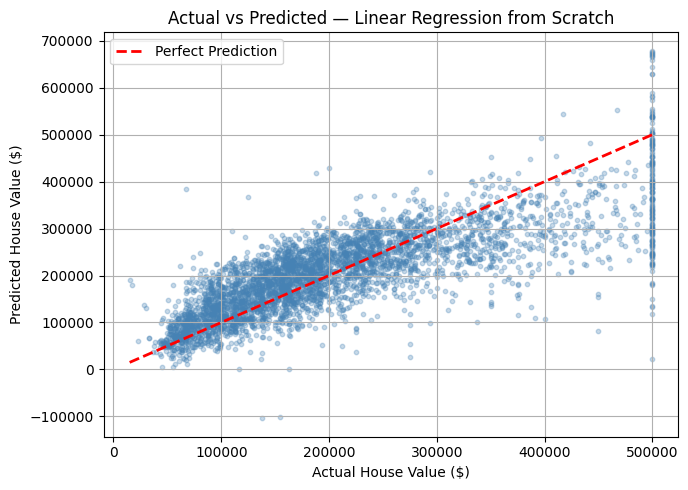

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(y_actual, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_actual.min(), y_actual.max()],
         [y_actual.min(), y_actual.max()],
         color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual House Value ($)")
plt.ylabel("Predicted House Value ($)")
plt.title("Actual vs Predicted — Linear Regression from Scratch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


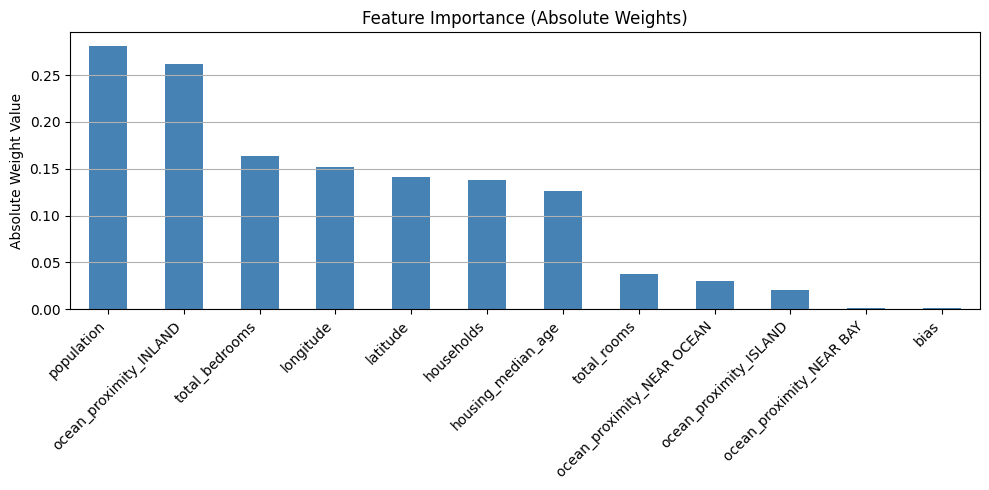

In [14]:
feature_names = ['bias'] + list(data.drop('median_house_value', axis=1).columns)

importance = pd.Series(
    np.abs(weights.flatten()),
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance[1:].plot(kind='bar', color='steelblue')  # skip bias term
plt.title("Feature Importance (Absolute Weights)")
plt.ylabel("Absolute Weight Value")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [15]:
sample_raw   = X_test[0].reshape(1, -1)
pred_norm    = sample_raw @ weights
pred_actual  = (pred_norm * y_std) + y_mean
actual_value = (y_test[0] * y_std) + y_mean

print(f"Predicted House Value : ${pred_actual[0][0]:,.2f}")
print(f"Actual House Value    : ${actual_value[0]:,.2f}")


Predicted House Value : $53,990.33
Actual House Value    : $47,700.00


In [19]:
# ============================================================
#   COMPARISON: Scratch vs Scikit-learn Linear Regression
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import time

# ── Scikit-learn Training ────────────────────────────────────
sk_model = LinearRegression()

start_sk = time.time()
sk_model.fit(X_train, y_train)
end_sk   = time.time()

# ── Predictions & Denormalize ────────────────────────────────
y_pred_sk_norm  = sk_model.predict(X_test)
y_pred_sk       = (y_pred_sk_norm  * y_std) + y_mean
y_pred_scr      = ((X_test @ weights) * y_std) + y_mean
y_actual        = (y_test * y_std) + y_mean

# ── Metrics Table ────────────────────────────────────────────
start_scr = time.time()
gradient_descent(X_train, y_train, learning_rate=0.01, epochs=1000)
end_scr   = time.time()

df_metrics = pd.DataFrame({
    "Model"         : ["From Scratch ", "Scikit-learn "],
    "MSE"           : [mean_squared_error(y_actual, y_pred_scr),
                       mean_squared_error(y_actual, y_pred_sk)],

    "R² Score"      : [r2_score(y_actual, y_pred_scr),
                       r2_score(y_actual, y_pred_sk)],
    "Train Time (s)": [round(end_scr - start_scr, 4),
                       round(end_sk  - start_sk,  4)]
})

print("\n" + "=" * 60)
print("           MODEL COMPARISON REPORT")
print("=" * 60)
print(df_metrics.to_string(index=False))
print("=" * 60)

Epoch     0 | Loss: 0.493843
Epoch   100 | Loss: 0.219388
Epoch   200 | Loss: 0.194690
Epoch   300 | Loss: 0.189563
Epoch   400 | Loss: 0.187130
Epoch   500 | Loss: 0.185468
Epoch   600 | Loss: 0.184191
Epoch   700 | Loss: 0.183166
Epoch   800 | Loss: 0.182325
Epoch   900 | Loss: 0.181625

           MODEL COMPARISON REPORT
        Model          MSE  R² Score  Train Time (s)
From Scratch  4.970809e+09  0.620667          0.5250
Scikit-learn  4.908477e+09  0.625424          0.0102
